#### **Padding & Strides in CNN**

In a **Convolutional Neural Network (CNN)**, **padding** and **stride** control how the convolution kernel moves over the input image and determine the size of the output feature map.

---

#### **Padding**

**Padding** means adding extra pixels around the border of an input image before applying convolution. For example, suppose we have a `4 × 4` image:

```text
1   2   3   4
5   6   7   8
9  10  11  12
13  14  15  16
```

If we add **one layer of zero padding**:

```text
0   0   0   0   0   0
0   1   2   3   4   0
0   5   6   7   8   0
0   9  10  11  12   0
0  13  14  15  16   0
0   0   0   0   0   0
```

The original `4 × 4` image becomes `6 × 6`.

#### **Why do we use padding?**

Padding is mainly used to:

1. **Preserve spatial dimensions**
2. Prevent information at the image borders from being ignored too quickly
3. Allow more convolution operations on border pixels

---

#### **Types of Padding**

**Valid Padding:** No padding is added. `padding = 0`. For example:

```text
Input:  4 × 4
Kernel: 2 × 2
Stride: 1
```

Output: `3 × 3`

---

**Same Padding:** Padding is used so that the output has approximately the same spatial dimensions as the input when `stride = 1`. For an odd-sized kernel such as `3 × 3`:

```text
Input:  4 × 4
Padding = 1
Output:  4 × 4
```

Visually:

```text
Original:

1  2  3  4
5  6  7  8
9 10 11 12
13 14 15 16
```

After padding:

```text
0  0  0  0  0  0
0  1  2  3  4  0
0  5  6  7  8  0
0  9 10 11 12  0
0 13 14 15 16  0
0  0  0  0  0  0
```

A `3 × 3` kernel with stride `1` produces `4 × 4`

---

#### **Stride**

**Stride** tells us how many pixels the kernel moves at each step.

**Stride = 1:** The kernel moves **one pixel at a time**. `→ 1 pixel`. For example:

```text
[Kernel] → 
    ↓
[Kernel] →
```

Every possible position is considered.

---

**Stride = 2:** The kernel moves **two pixels at a time**.

```text
[Kernel] →→
          ↓
[Kernel] →→
```

This skips some positions and therefore produces a **smaller feature map**.

---

#### **Example: Stride = 1**

Suppose:

```text
Input = 5 × 5
Kernel = 3 × 3
Padding = 0
Stride = 1
```

Output size `3 × 3` Because `5 - 3 + 1 = 3`. So

```text
5 × 5
   ↓
Convolution
   ↓
3 × 3
```


---

#### **Output Size Formula**

For a 2D convolution:

$$
Output = \left\lfloor
\frac{N + 2P - K}{S}
\right\rfloor + 1
$$

Where:

| Symbol | Meaning     |
| ------ | ----------- |
| `N`    | Input size  |
| `P`    | Padding     |
| `K`    | Kernel size |
| `S`    | Stride      |

For height:

$$
H_{out} =
\left\lfloor
\frac{H_{in}+2P-K}{S}
\right\rfloor+1
$$

For width:

$$
W_{out} =
\left\lfloor
\frac{W_{in}+2P-K}{S}
\right\rfloor+1
$$

---

**Example 1:**

```text
Input = 32 × 32
Kernel = 3 × 3
Padding = 0
Stride = 1
```

$$
\frac{32+0-3}{1}+1=30
$$

Output `30 × 30`

---

**Example 2:**

```text
Input = 32 × 32
Kernel = 3 × 3
Padding = 1
Stride = 1
```

$$
\frac{32+2(1)-3}{1}+1=32
$$

Output `32 × 32`. This is commonly called **same convolution**.

---

**Example 3:**

```text
Input = 32 × 32
Kernel = 3 × 3
Padding = 1
Stride = 2
```

$$
\frac{32+2(1)-3}{2}+1
=16
$$

Output `16 × 16`. So stride can be used to **downsample** an image.

---

#### **Padding vs Stride**

| Padding                     | Stride                         |
| --------------------------- | ------------------------------ |
| Adds pixels around input    | Controls kernel movement       |
| Helps preserve size         | Controls output size           |
| Usually adds zeros          | Can be `1`, `2` etc.           |
| Protects border information | Can downsample the feature map |
| Example: `padding=1`        | Example: `stride=2`            |

Think of it this way:

```text
Padding: "How much extra border should I add?"
Stride: "How far should the kernel move each time?"
```

---

#### **PyTorch Example**

In PyTorch, we specify padding and stride inside `nn.Conv2d`:

```python
import torch
import torch.nn as nn

conv = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    stride=1,
    padding=1
)
```

#### **Pooling Layer in CNN — Max Pooling**

**Max Pooling** reduces the size of a feature map while keeping the **most important/highest activation** from each region.

#### **Example: 2×2 Max Pooling, Stride = 2**

```text
INPUT FEATURE MAP (4×4)
┌─────┬─────┬─────┬─────┐
│  1  │  3  │  2  │  4  │
├─────┼─────┼─────┼─────┤
│  5  │  6  │  7  │  8  │
├─────┼─────┼─────┼─────┤
│  9  │ 10  │ 11  │ 12  │
├─────┼─────┼─────┼─────┤
│ 13  │ 14  │ 15  │ 16  │
└─────┴─────┴─────┴─────┘
       │ 2×2 Pooling Window, Stride = 2
       ▼
┌─────────────┐
│  1       3  │
│  5       6  │
└─────────────┘
       │ MAX = 6
       ▼
┌─────────────┬─────────────┐
│      6      │      8      │
├─────────────┼─────────────┤
│     14      │     16      │
└─────────────┴─────────────┘
OUTPUT FEATURE MAP (2×2)
```

#### **How it works**

```text
        2×2 window
       ┌───┬───┐
       │ 1 │ 3 │
       ├───┼───┤
       │ 5 │ 6 │
       └───┴───┘
           ↓
       MAX = 6
```

The pooling window then **jumps 2 pixels** because **Stride = 2**.

```text
Position 1        Position 2
┌───┬───┐         ┌───┬───┐
│ 1 │ 3 │  → → →  │ 2 │ 4 │
├───┼───┤         ├───┼───┤
│ 5 │ 6 │         │ 7 │ 8 │
└───┴───┘         └───┴───┘
 MAX = 6            MAX = 8
```

#### **Main idea**

**Convolution:** detects features
**Max Pooling:** keeps the strongest feature and reduces spatial size

```text
Feature Map
    ▼
┌──────────────┐
│ Max Pooling  │
│   2 × 2      │
│   Stride 2   │
└──────────────┘
    ▼
Smaller Feature Map
```

**4×4 → 2×2**: So, max pooling helps CNNs **reduce computation, reduce spatial dimensions, and retain strong features**.
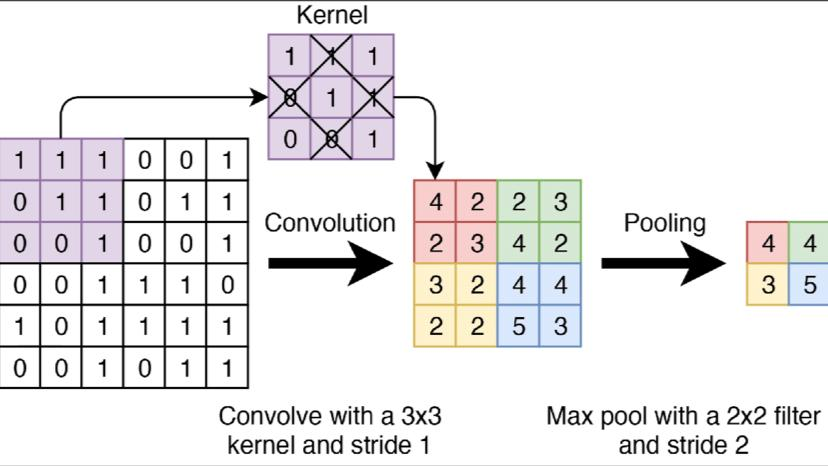